## qsoabsfind example notebook

Below I show a few examples to run `qsoabsfind` explore its output.

In [ ]:
# basic imports
import numpy as np
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt

### Details of input file (DESI DR1 Spectra)

In [ ]:
# exploring ..data/desi/qso_test_spectra.fits file
hdul = fits.open(f'../data/desi/qso_test_spectra.fits')
header = hdul[0].header
hdul.close()
print(header)

- I have already run `qsoabsfind` on `../data/desi/qso_test_spectra.fits` and saved the results as `../data/desi/MgII_cat.fits` and `../data/desi/CIV_cat.fits`.

### Exploring output

Reading extension 'PRIMARY' (PrimaryHDU)
Reading extension 'ABSORBER' (BinTableHDU)
Reading extension 'METADATA' (BinTableHDU)
Reading extension 'QSO_INFO' (BinTableHDU)
Reading extension 'COLUMN_DENSITY' (BinTableHDU)
Loaded 5 extensions from ../data/desi/MgII_cat.fits
  ABSORBER: 34 rows
  METADATA: 34 rows
  COLUMN_DENSITY: 34 rows
  QSO_INFO: 100 rows
INFO: Time taken to read catalog from ../data/desi/MgII_cat.fits 0.05 seconds


Text(0.5, 0, 'MgII redshift')

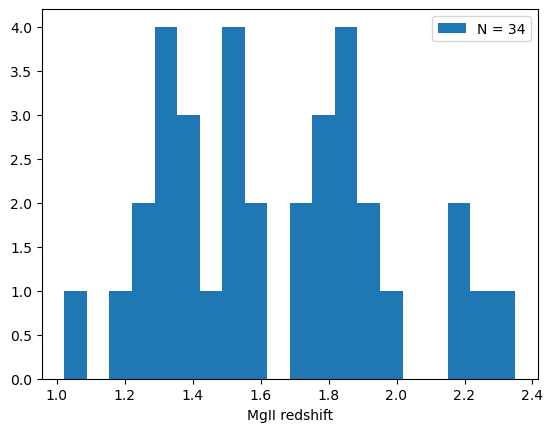

In [16]:
from qsoabsfind.datamodel import AbsorberData
mgii_tab = AbsorberData(f'../data/desi/MgII_cat.fits', autoload=True)
zabs = mgii_tab.catalog["Z_ABS"].data
plt.hist(zabs, bins=20, label = f'N = {zabs.size}')
plt.legend()
plt.xlabel('MgII redshift')

In [ ]:
ew1 = mgii_tab.catalog["MGII_2796_EW"].data
ew2 = mgii_tab.catalog["MGII_2803_EW"].data
bins = np.arange(0.1, 3.5, 0.1)
plt.hist(ew1, bins=bins, label='ew1')
plt.hist(ew2, bins=bins, label = 'ew2')
plt.legend()
plt.xlabel(r'$EW_{\rm MgII}\, [\AA]$')

### Plotting spectra

INFO: plotting QSO INDEX = 18...
INFO: Time taken to read ../data/desi/qso_test_spectra.fits 0.02 seconds


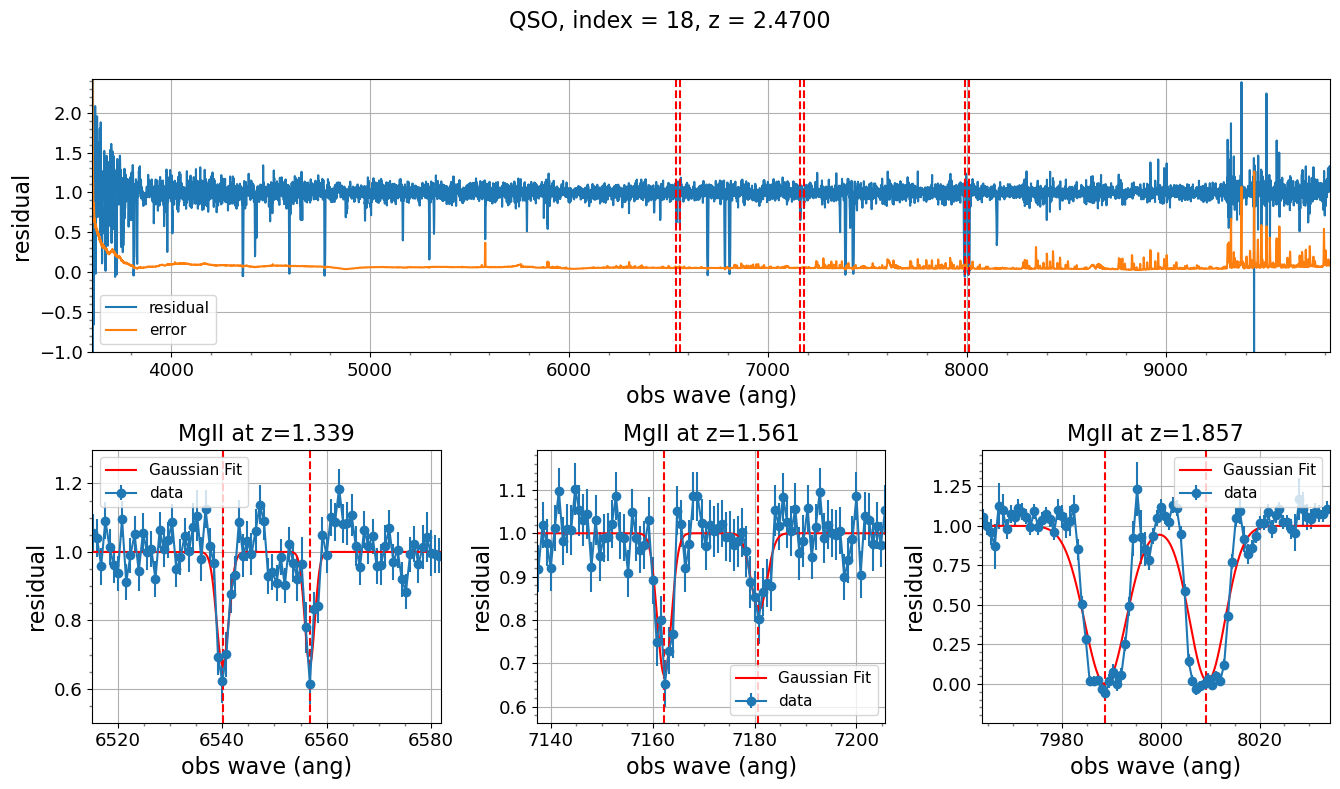

In [ ]:
from qsoabsfind.utils import plot_absorber
from qsoabsfind.datamodel import QSOSpecRead
import numpy as np

# select a random spectra from MgII_cat.fits
index = np.random.choice(mgii_tab.catalog["INDEX_SPEC"].data)
print(f'INFO: plotting QSO INDEX = {index}...')
spectra = QSOSpecRead(f'../data/desi/qso_test_spectra.fits', index=index, autoload=True)

# select corresponding zabs table
zabs = mgii_tab.catalog[mgii_tab.catalog["INDEX_SPEC"].data==index]
plot_absorber(spectra, 'MgII', zabs, show_error=True, xlabel='obs wave (ang)', \
              ylabel='residual', title=f'QSO, index = {index}, z = {spectra.metadata["Z_QSO"]:.4f}', plot_filename=None)

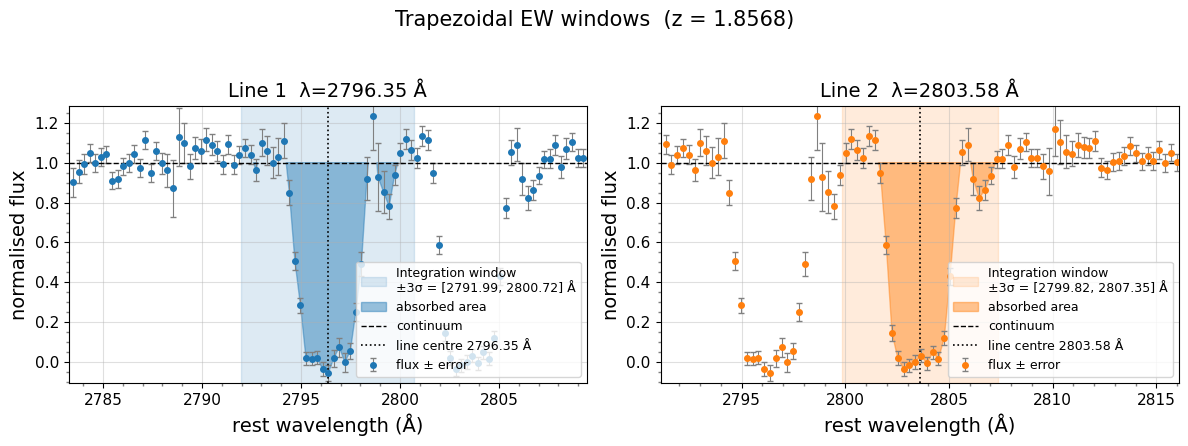

In [27]:
from qsoabsfind.utils import plot_trapezoidal_ew_windows

z = zabs["Z_ABS"][-1]
gauss_fit = zabs["GAUSS_FIT"][-1]
line1, line2 = gauss_fit[1], gauss_fit[4]
sigma1, sigma2 = gauss_fit[2], gauss_fit[5]


plot_trapezoidal_ew_windows(
    spectra.wavelength, spectra.flux, spectra.error, z=z,
    line1=line1, line2=line2,
    sigma1=sigma1, sigma2=sigma2,
    n_sigma=3,
)

### Using qsoabsfind internally as module

In [19]:
# if want to run qsoabsfind on one spectrum
from qsoabsfind.absfinder import read_single_spectrum_and_find_absorber
from qsoabsfind.config import load_constants
help(read_single_spectrum_and_find_absorber)

Help on function read_single_spectrum_and_find_absorber in module qsoabsfind.absfinder:

read_single_spectrum_and_find_absorber(fits_file, spec_index, absorber, **kwargs)
    This function retrieves a single QSO spectrum from a FITS file, processes the data to remove NaNs,
    and prepares the spectrum for absorber search within specified wavelength regions
    and runs the convolution based adaptive S/N method to detect absorbers in the spectrum.
    
    Args:
        fits_file (str): Path to the FITS file containing normalized QSO spectra.
                         The file must include extensions for FLUX, ERROR, WAVELENGTH
                         and METADATA which must contain keyword Z_QSO.
        spec_index (int): Index of the quasar spectrum to retrieve from the FITS file.
        absorber (str): Name of the absorber to search for (e.g., MgII, CIV, OVI, NV, SiIV, AlIII, FeII, CaII, NaI).
        kwargs (dict): search parameters as taken in convolution_method..()
            A

In [20]:
parameters = load_constants(f'../data/desi/desi_constants.py')
read_single_spectrum_and_find_absorber(f'../data/desi/qso_test_spectra.fits', index, 'MgII', **parameters.search_parameters)

/Users/abhijeet/software/myprojects/qsoabsfind/qsoabsfind/ew.py:77: RuntimeWarning: invalid value encountered in sqrt
  save_param_error = np.sqrt(np.diag(pcov))
/Users/abhijeet/opt/anaconda3/envs/my_software/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/Users/abhijeet/software/myprojects/qsoabsfind/qsoabsfind/ew.py:77: RuntimeWarning: invalid value encountered in sqrt
  save_param_error = np.sqrt(np.diag(pcov))


{'index_spec': [18, 18, 18],
 'z_abs': [1.3387884161994958, 1.5612976424315916, 1.8568447029907533],
 'gauss_fit': [[0.3299112115564003,
   2796.351020624479,
   0.4971149386009211,
   0.32999226226881556,
   2803.4926829044657,
   0.41484866632005857],
  [0.3276008211425697,
   2796.3505552699517,
   0.5384448214224324,
   0.1767711369483922,
   2803.6058732138868,
   0.6235951213919552],
  [1.0035861418309964,
   2796.351364827295,
   1.4545804008781298,
   0.9839973975921392,
   2803.584035294476,
   1.2558226569024609]],
 'gauss_fit_std': [[0.04668447524293156,
   0.0735543252758753,
   0.07440212536584598,
   0.05031068270528778,
   0.07739027090638695,
   0.07455857652732938],
  [0.03827433255452179,
   0.07310962561916572,
   0.07294203909307444,
   0.036707294559638226,
   0.1536143530146299,
   0.15274995238056044],
  [0.016790224046633356,
   0.03376212566844589,
   0.042288364455073696,
   0.015191012863409483,
   0.02593821946454435,
   0.030241989555293232]],
 'ew_1_mean':

In [ ]:
civ_tab = AbsorberData(f'../data/desi/CIV_cat.fits', autoload=True)
civ_zabs = civ_tab.catalog["Z_ABS"].data
plt.hist(civ_zabs, bins=20, label = f'N = {civ_zabs.size}')
plt.legend()
plt.xlabel('CIV redshift')

In [ ]:
from qsoabsfind.utils import plot_absorber
from qsoabsfind.datamodel import QSOSpecRead

# select a random spectra from MgII_cat.fits
index1 = np.random.choice(civ_tab.catalog["INDEX_SPEC"].data)
spectra = QSOSpecRead(f'../data/desi/qso_test_spectra.fits', index=index1, autoload=True)
print(f'INFO: plotting CIV for QSO INDEX = {index1}...')
# select corresponding zabs table
zabs = civ_tab.catalog[civ_tab.catalog["INDEX_SPEC"].data==index1]
plot_absorber(spectra, 'CIV', zabs, show_error=True, xlabel='obs wave (ang)', \
              ylabel='residual', title=f'QSO, index = {index1}, z = {spectra.metadata["Z_QSO"]:.4f}', plot_filename=None)

NameError: name 'civ_tab' is not defined